<a href="https://colab.research.google.com/github/Elizabeth5335/winning-factors-in-tennis/blob/main/tennis_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project and Data Overview

Link to Tableau: [Winning Factors in Tennis](https://public.tableau.com/app/profile/yelyzaveta.cherkasova/viz/WinningFactorsinTennis/Dashboard1?publish=yes)


The **goal** of this project is to identify which player characteristics and match conditions are associated with the probability of winning a tennis match. For this I used tennis ATP dataset, gathering data about tennis matches from 1968 to 2024.

The original dataset contains 194996 match-level observations (rows) with 49 features (columns).

For analysis, the dataset was transformed into a player-match format, where each match is represented by two observations (one per player). Performance-related variables (e.g., aces, double faults) were removed to focus on pre-match characteristics.

Final dataset contains 389992 rows and 16 columns.

**Data types**

* To optimize memory usage, the binary target variable `win` was converted to `int8`.
* The `date` column was converted to a datetime format for time-based analysis.

**Outliers & Errors**

* Outliers in `player_height` and `opponent_height` were handled by removing values below 150 cm, based on known minimum heights of professional ATP players.
* Players younger than 16 were also removed, as they fall outside the typical range of professional ATP competition.
* During the analysis, matches labeled as level "F" showed inconsistent patterns compared to other tournament levels, suggesting potential data quality issues. Therefore, this category was excluded from further analysis.


**Missing Values**

Columns with a small proportion of missing values (~1.5%), such as `surface`, `player_age`, and `player_hand`, were handled by dropping missing rows.

Columns with higher missingness required a different approach:
* `player/opponent_height` (~11% missing): after outlier removal, the distribution was approximately symmetric, so missing values were imputed using the mean.
* `player/opponent_rank` (~20% missing): due to strong right skewness, imputation (mean/median) would distort the distribution. Therefore, missing values were preserved and excluded from analyses requiring this feature.


**Duplicates**

Two types of duplicates were identified:
* Full duplicates: 24
* Match-level duplicates (based on `date`, `player`, `opponent`, `tourney_id`): 116

*All duplicates were removed to ensure data consistency.*


In [3]:
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

##Creating dataset

In [4]:
from google.colab import drive
import glob

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Projects/Tennis

files = glob.glob("atp_matches_*.csv")

dfs = [pd.read_csv(file) for file in files]

matches = pd.concat(dfs, ignore_index=True)
matches.head()

Mounted at /content/drive
/content/drive/MyDrive/Projects/Tennis


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2012-339,Brisbane,Hard,32.0,A,20120101,1,104918,1.0,NaN,...,41.0,29.0,15.0,14.0,4.0,9.0,4.0,7380.0,91.0,598.0
1,2012-339,Brisbane,Hard,32.0,A,20120101,2,104180,NaN,NaN,...,67.0,54.0,20.0,16.0,1.0,2.0,54.0,893.0,85.0,630.0
2,2012-339,Brisbane,Hard,32.0,A,20120101,3,104571,NaN,NaN,...,48.0,36.0,17.0,11.0,2.0,4.0,44.0,940.0,79.0,658.0
3,2012-339,Brisbane,Hard,32.0,A,20120101,4,105453,5.0,NaN,...,49.0,27.0,23.0,13.0,9.0,14.0,25.0,1430.0,81.0,652.0
4,2012-339,Brisbane,Hard,32.0,A,20120101,5,104797,NaN,NaN,...,38.0,28.0,11.0,9.0,0.0,0.0,73.0,685.0,23.0,1630.0


In [5]:
print(f"Rows: {matches.shape[0]}; Columns: {matches.shape[1]}")

Rows: 194996; Columns: 49


In [6]:
matches.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'],
      dtype='object')

In [7]:
# Transform dataset to player-match format
# 1. Create winners and losers datasets
# 2. Remove unnecessary columns (performance variables and technical details)
# 3. Concatenate winners and loosers

winners = matches[['tourney_id', 'tourney_date','surface','tourney_level', 'round',
              'winner_name','winner_age','winner_ht','winner_rank', 'winner_hand',
              'loser_name','loser_age','loser_ht','loser_rank', 'loser_hand']].copy()

winners.columns = ['tourney_id', 'date','surface','level', 'round',
                   'player','player_age','player_height','player_rank', 'player_hand',
                   'opponent','opponent_age','opponent_height','opponent_rank', 'opponent_hand']

winners['win'] = 1


losers = matches[['tourney_id', 'tourney_date','surface','tourney_level', 'round',
              'loser_name','loser_age','loser_ht','loser_rank', 'loser_hand',
              'winner_name','winner_age','winner_ht','winner_rank', 'winner_hand']].copy()

losers.columns = ['tourney_id', 'date','surface','level', 'round',
                   'player','player_age','player_height','player_rank', 'player_hand',
                   'opponent','opponent_age','opponent_height','opponent_rank', 'opponent_hand']

losers['win'] = 0


df = pd.concat([winners, losers], ignore_index=True)
df.head()

,tourney_id,date,surface,level,round,player,player_age,player_height,player_rank,player_hand,opponent,opponent_age,opponent_height,opponent_rank,opponent_hand,win
0,2012-339,20120101,Hard,A,R32,Andy Murray,24.6,191.0,4.0,R,Mikhail Kukushkin,24.0,183.0,91.0,R,1
1,2012-339,20120101,Hard,A,R32,Gilles Muller,28.6,193.0,54.0,L,Ricardo Mello,31.0,175.0,85.0,L,1
2,2012-339,20120101,Hard,A,R32,Marcos Baghdatis,26.5,183.0,44.0,R,Ryan Harrison,19.6,185.0,79.0,R,1
3,2012-339,20120101,Hard,A,R32,Kei Nishikori,22.0,178.0,25.0,R,Cedrik Marcel Stebe,21.2,183.0,81.0,L,1
4,2012-339,20120101,Hard,A,R32,Denis Istomin,25.3,185.0,73.0,R,Florian Mayer,28.2,190.0,23.0,R,1


##Data Cleaning

In [8]:
df.head()

,tourney_id,date,surface,level,round,player,player_age,player_height,player_rank,player_hand,opponent,opponent_age,opponent_height,opponent_rank,opponent_hand,win
0,2012-339,20120101,Hard,A,R32,Andy Murray,24.6,191.0,4.0,R,Mikhail Kukushkin,24.0,183.0,91.0,R,1
1,2012-339,20120101,Hard,A,R32,Gilles Muller,28.6,193.0,54.0,L,Ricardo Mello,31.0,175.0,85.0,L,1
2,2012-339,20120101,Hard,A,R32,Marcos Baghdatis,26.5,183.0,44.0,R,Ryan Harrison,19.6,185.0,79.0,R,1
3,2012-339,20120101,Hard,A,R32,Kei Nishikori,22.0,178.0,25.0,R,Cedrik Marcel Stebe,21.2,183.0,81.0,L,1
4,2012-339,20120101,Hard,A,R32,Denis Istomin,25.3,185.0,73.0,R,Florian Mayer,28.2,190.0,23.0,R,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389992 entries, 0 to 389991
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   tourney_id       389992 non-null  object 
 1   date             389992 non-null  int64  
 2   surface          384012 non-null  object 
 3   level            389992 non-null  object 
 4   round            389992 non-null  object 
 5   player           389992 non-null  object 
 6   player_age       384035 non-null  float64
 7   player_height    344168 non-null  float64
 8   player_rank      310047 non-null  float64
 9   player_hand      389978 non-null  object 
 10  opponent         389992 non-null  object 
 11  opponent_age     384035 non-null  float64
 12  opponent_height  344168 non-null  float64
 13  opponent_rank    310047 non-null  float64
 14  opponent_hand    389978 non-null  object 
 15  win              389992 non-null  int64  
dtypes: float64(6), int64(2), object(8)
mem

In [10]:
# Datatypes

df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
df['win'] = df['win'].astype('int8')
df.dtypes

,0
tourney_id,object
date,datetime64[ns]
surface,object
level,object
round,object
player,object
player_age,float64
player_height,float64
player_rank,float64
player_hand,object


In [11]:
print(f"Rows: {df.shape[0]}; Columns: {df.shape[1]}")

Rows: 389992; Columns: 16


####**Outliers and errors**

In [12]:
df.describe()

,date,player_age,player_height,player_rank,opponent_age,opponent_height,opponent_rank,win
count,389992,384035.000000,344168.000000,310047.000000,384035.000000,344168.000000,310047.000000,389992.000000
mean,1994-08-01 11:07:35.861658880,25.709128,184.450725,93.595548,25.709128,184.450725,93.595548,0.500000
min,1967-12-28 00:00:00,14.200000,3.000000,1.000000,14.200000,3.000000,1.000000,0.000000
25%,1980-07-14 00:00:00,22.700000,180.000000,25.000000,22.700000,180.000000,25.000000,0.000000
50%,1993-10-04 00:00:00,25.300000,185.000000,57.000000,25.300000,185.000000,57.000000,0.500000
75%,2007-12-31 00:00:00,28.300000,188.000000,101.000000,28.300000,188.000000,101.000000,1.000000
max,2024-12-18 00:00:00,63.600000,211.000000,2159.000000,63.600000,211.000000,2159.000000,1.000000
std,NaN,4.131891,6.775834,144.233528,4.131891,6.775834,144.233528,0.500001


In [13]:
# Find the errors in player_height (using other open data to find minimum height of ATP players)
# Remove values that are less than threashold

print(df[df['player_height'] < 150]['player_height'].value_counts())
df.drop(df[df['player_height'] < 150].index, inplace=True)

df.drop(df[df['opponent_height'] < 150].index, inplace=True)


# After removing
print("After removing: ")
df[['player_height', 'opponent_height']].describe()

player_height
3.0     5
71.0    3
15.0    3
Name: count, dtype: int64
After removing: 


,player_height,opponent_height
count,344147.000000,344147.000000
mean,184.455735,184.455735
std,6.713593,6.713593
min,160.000000,160.000000
25%,180.000000,180.000000
50%,185.000000,185.000000
75%,188.000000,188.000000
max,211.000000,211.000000


In [14]:
# Checking age
print(df[df['player_age'] < 15][['date', 'player', 'player_age']].sort_values(by='player_age'))

# Remove players who are too young
df = df[df['player_age'] >= 16]
df = df[df['opponent_age'] >= 16]

             date                            player  player_age
239415 1968-03-18                    Emilio Montano        14.2
139177 1992-03-27                     Laith Azzouni        14.3
296048 1969-03-31                  Freddie De Jesus        14.4
268272 1989-08-07                       Peter Hajek        14.4
251783 2018-02-03               Ainius Sabaliauskas        14.5
273534 1970-11-09                      David Carter        14.5
239559 1968-03-18                       Jose Moreno        14.5
78542  1970-11-09                      David Carter        14.5
389804 1977-04-22                    Tarek El Sakka        14.5
296090 1969-03-17                        Sam Vuille        14.6
366698 1978-08-14                        Ali Madani        14.6
204555 2004-04-09  Daniel Alejandro Lopez Cassaccia        14.7
334173 1992-03-27                        Derek Yong        14.7
236112 1968-06-07                       Jose Moreno        14.7
233424 1991-05-10                 Tawfik

In [15]:
# Checking age (old people)
print(df[df['player_age'] > 50][['date', 'player', 'player_age']])

# the only visible error with ages is Anthony Billington's age. He had 5 games, so can be removed from the dataset

df.drop(df[df['player'] == "Anthony Billington"].index, inplace=True)

df.drop(df[df['opponent'] =="Anthony Billington"].index, inplace=True)

             date              player  player_age
42267  1968-03-04      Gardnar Mulloy        54.2
114254 1971-12-13       Pancho Segura        50.4
167472 1972-07-06       Ted Schroeder        50.9
180484 1976-09-24       James Mcardle        56.3
236443 1968-08-29        Frank Parker        52.5
237245 1968-03-04      Gardnar Mulloy        54.2
237740 1968-07-22  Anthony Billington        58.6
237968 1968-08-17  Anthony Billington        58.7
238367 1968-07-29  Anthony Billington        58.7
238613 1968-08-05  Anthony Billington        58.7
243330 1973-07-09       James Mcardle        53.1
270526 1970-07-06       James Mcardle        50.1
272516 1970-07-06      Fritz Kuhlmann        63.6
272976 1970-03-25      Gardnar Mulloy        56.3
272989 1970-03-25      Fritz Kuhlmann        63.4
295345 1969-05-23          Rene Ruzic        50.2
296078 1969-03-17      Gardnar Mulloy        55.3
296207 1969-06-09  Anthony Billington        59.5
306348 1971-07-05       James Mcardle        51.1


####**Distributions**

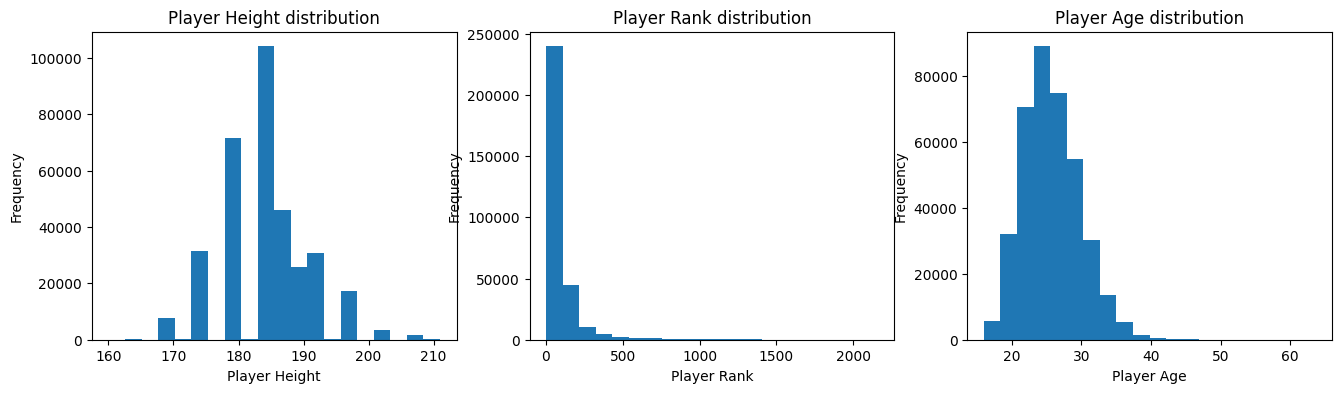

In [16]:
# Distribution tests

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].hist(df['player_height'], bins=20)
ax[0].set_xlabel('Player Height')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Player Height distribution')


ax[1].hist(df['player_rank'], bins=20)
ax[1].set_xlabel('Player Rank')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Player Rank distribution')

ax[2].hist(df['player_age'], bins=20)
ax[2].set_xlabel('Player Age')
ax[2].set_ylabel('Frequency')
ax[2].set_title('Player Age distribution')
plt.show()

In [17]:
# Tests show that distributions are not normal (p-value is less than 0.05)

heights = df['player_height'].dropna()
ranks = df['player_rank'].dropna()
ages = df['player_age'].dropna()

stat1, p1 = stats.normaltest(heights)
stat2, p2 = stats.normaltest(ranks)
stat3, p3 = stats.normaltest(ages)


print(f"player_height normality stats={stat1:.2f}, p-value: {p1:.2e}")
print(f"\nplayer_rank normality stats={stat2:.2f}, p-value: {p2:.2e}")
print(f"\nplayer_age normality stats={stat3:.2f}, p-value: {p3:.2e}")

player_height normality stats=3904.88, p-value: 0.00e+00

player_rank normality stats=309730.88, p-value: 0.00e+00

player_age normality stats=23513.36, p-value: 0.00e+00


####**Missing values**

In [18]:
# Missing Values

print("Missing data in columns:")
missing_cols = df.loc[:, df.isna().sum() > 0]
print(missing_cols.isna().sum())
print("\n% of missing data in columns:")
print(missing_cols.isna().sum()/df.shape[0] * 100)

# Decision:
# % of missing data in surface, player/opponent_age, player/opponent_hand columns is insignificant (~1.5%), so rows with missing values were dropped.
# Height and rank columns have 11% and 20% missing values respectively, so rows cannot be dropped.
# After removing outliers, height distribution is approximately symmetrical, so missing values were filled with the mean.
# player_rank has 20% missing values with strong right skewness. Filling with mean or median would artificially distort the distribution,
# so missing values are left as-is and will be excluded during pairwise analysis.

df = df.dropna(subset=['surface', 'player_age', 'opponent_age', 'player_hand', 'opponent_hand'])

df['player_height'] = df['player_height'].fillna(df['player_height'].mean())
df['opponent_height'] = df['opponent_height'].fillna(df['opponent_height'].mean())

print("\n% of missing data in columns:")
print(df.loc[:, df.isna().sum() > 0].isna().sum()/df.shape[0] * 100)

Missing data in columns:
surface             4732
player_height      37380
player_rank        70091
player_hand            4
opponent_height    37380
opponent_rank      70091
opponent_hand          4
dtype: int64

% of missing data in columns:
surface             1.248832
player_height       9.865035
player_rank        18.497865
player_hand         0.001056
opponent_height     9.865035
opponent_rank      18.497865
opponent_hand       0.001056
dtype: float64

% of missing data in columns:
player_rank      17.860407
opponent_rank    17.860407
dtype: float64


####**Duplicates**

In [19]:
df.head()

,tourney_id,date,surface,level,round,player,player_age,player_height,player_rank,player_hand,opponent,opponent_age,opponent_height,opponent_rank,opponent_hand,win
0,2012-339,2012-01-01,Hard,A,R32,Andy Murray,24.6,191.0,4.0,R,Mikhail Kukushkin,24.0,183.0,91.0,R,1
1,2012-339,2012-01-01,Hard,A,R32,Gilles Muller,28.6,193.0,54.0,L,Ricardo Mello,31.0,175.0,85.0,L,1
2,2012-339,2012-01-01,Hard,A,R32,Marcos Baghdatis,26.5,183.0,44.0,R,Ryan Harrison,19.6,185.0,79.0,R,1
3,2012-339,2012-01-01,Hard,A,R32,Kei Nishikori,22.0,178.0,25.0,R,Cedrik Marcel Stebe,21.2,183.0,81.0,L,1
4,2012-339,2012-01-01,Hard,A,R32,Denis Istomin,25.3,185.0,73.0,R,Florian Mayer,28.2,190.0,23.0,R,1


In [20]:
print("Full duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("Match duplicates:", df.duplicated(
    subset=['date', 'player', 'opponent', 'tourney_id']
).sum())

df.drop_duplicates(subset=['date', 'player', 'opponent', 'tourney_id'], inplace=True)

print("Duplicates removed!")

Full duplicated: 24
Match duplicates: 116
Duplicates removed!


In [21]:
print(f"After Cleaning:\nNumber of matches: {df.shape[0]}")
print(f"Number of players: {df['player'].nunique()}")

After Cleaning:
Number of matches: 374034
Number of players: 5288


##Exploratory Analysis

###**General Overview**

In [22]:
df.head()

,tourney_id,date,surface,level,round,player,player_age,player_height,player_rank,player_hand,opponent,opponent_age,opponent_height,opponent_rank,opponent_hand,win
0,2012-339,2012-01-01,Hard,A,R32,Andy Murray,24.6,191.0,4.0,R,Mikhail Kukushkin,24.0,183.0,91.0,R,1
1,2012-339,2012-01-01,Hard,A,R32,Gilles Muller,28.6,193.0,54.0,L,Ricardo Mello,31.0,175.0,85.0,L,1
2,2012-339,2012-01-01,Hard,A,R32,Marcos Baghdatis,26.5,183.0,44.0,R,Ryan Harrison,19.6,185.0,79.0,R,1
3,2012-339,2012-01-01,Hard,A,R32,Kei Nishikori,22.0,178.0,25.0,R,Cedrik Marcel Stebe,21.2,183.0,81.0,L,1
4,2012-339,2012-01-01,Hard,A,R32,Denis Istomin,25.3,185.0,73.0,R,Florian Mayer,28.2,190.0,23.0,R,1


In [23]:
# Overview

print(f"Dataset contains data from {df['date'].dt.date.min()} to {df['date'].dt.date.max()}")
print(f"Number of matches: {df.shape[0]}")
print(f"Number of players: {df['player'].nunique()}")


# Dimensions
print(f"\nSurfaces: {df['surface'].unique()}")
print(df['surface'].value_counts())

print(f"\nLevels: {df['level'].unique()}")
print(df['level'].value_counts())


print(f"\nRounds: {df['round'].unique()}")
print(df['round'].value_counts())


Dataset contains data from 1967-12-28 to 2024-12-18
Number of matches: 374034
Number of players: 5288

Surfaces: ['Hard' 'Clay' 'Grass' 'Carpet']
surface
Hard      154006
Clay      134824
Grass      43956
Carpet     41248
Name: count, dtype: int64

Levels: ['A' 'G' 'D' 'M' 'F' 'O']
level
A    243368
G     54496
M     48226
D     26666
F      1150
O       128
Name: count, dtype: int64

Rounds: ['R32' 'R16' 'QF' 'SF' 'F' 'R128' 'R64' 'RR' 'BR' 'ER']
round
R32     121376
R16      66276
R64      62398
QF       34244
RR       31761
R128     31270
SF       17597
F         8929
BR         120
ER          63
Name: count, dtype: int64


In [24]:
df['player_hand'].value_counts()

,count
player_hand,
R,317477
L,52912
U,3408
A,237


In [25]:
# Add columns with metrics differences

df['rank_diff'] = df['player_rank'] - df['opponent_rank']
df['age_diff'] = df['player_age'] - df['opponent_age']
df['height_diff'] = df['player_height'] - df['opponent_height']

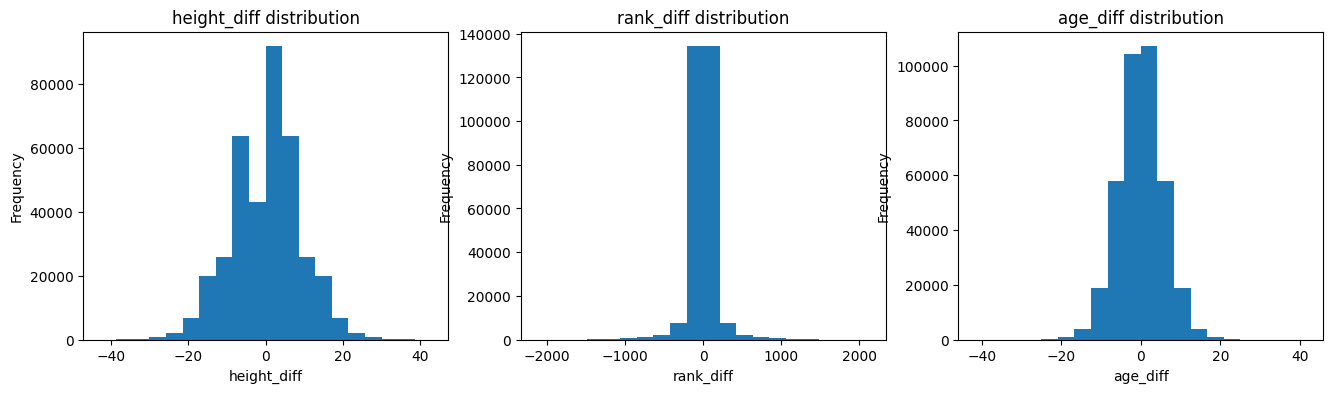

In [26]:
# Distributions
# All Distributions are symmetric, but not normal

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].hist(df['height_diff'], bins=20)
ax[0].set_xlabel('height_diff')
ax[0].set_ylabel('Frequency')
ax[0].set_title('height_diff distribution')


ax[1].hist(df['rank_diff'], bins=20)
ax[1].set_xlabel('rank_diff')
ax[1].set_ylabel('Frequency')
ax[1].set_title('rank_diff distribution')

ax[2].hist(df['age_diff'], bins=20)
ax[2].set_xlabel('age_diff')
ax[2].set_ylabel('Frequency')
ax[2].set_title('age_diff distribution')
plt.show()

In [27]:
# Tests show that distributions are not normal (p-value is less than 0.05)

heights = df['height_diff'].dropna()
ranks = df['rank_diff'].dropna()
ages = df['age_diff'].dropna()

stat1, p1 = stats.normaltest(heights)
stat2, p2 = stats.normaltest(ranks)
stat3, p3 = stats.normaltest(ages)

print(f"height_diff normality stats={stat1:.2f}, p-value: {p1:.2e}")
print(f"rank_diff normality stats={stat2:.2f}, p-value: {p2:.2e}")
print(f"age_diff normality stats={stat3:.2f}, p-value: {p3:.2e}")


height_diff normality stats=1277.50, p-value: 3.94e-278
rank_diff normality stats=71239.86, p-value: 0.00e+00
age_diff normality stats=2708.92, p-value: 0.00e+00


In [29]:
df['round'].unique()

array(['R32', 'R16', 'QF', 'SF', 'F', 'R128', 'R64', 'RR', 'BR', 'ER'],
      dtype=object)

In [30]:
# Add additional column for round group

def round_group(r):
    if r in ['R128', 'R64', 'R32', 'R16']:
        return 'Early'
    elif r in ['QF', 'SF']:
        return 'Middle'
    elif r == 'F':
        return 'Final'
    else:  # RR, BR, ER
        return 'Special'

df['round_group'] = df['round'].apply(round_group)

###**Correlations**

In [28]:
def chi_test(metric_1, metric_2, metric_3=None):

  if metric_3 is None:
        contingency = pd.crosstab(df[metric_1], df[metric_2])
        col_name = metric_2
        print("Contingency table for:")
        print(contingency)
        print("\n")
  else:
        contingency = pd.crosstab(index=[df[metric_1], df[metric_2]], columns=df[metric_3])
        col_name = metric_3


  chi2, p, dof, expected = stats.chi2_contingency(contingency)

  print(f"Chi2={chi2:.2f}, p={p:.3e}")

  if p < 0.05:
      print(f"There is a statistically significant association between {metric_1}, {metric_2}.\n")
  else:
      print(f"NO statistically significant association found.\n")

####**Player Hand**

Contingency table for:
win               0       1
player_hand                
A               137     100
L             25526   27386
R            158754  158723
U              2569     839


Chi2=949.35, p=1.746e-205
There is a statistically significant association between player_hand, win.



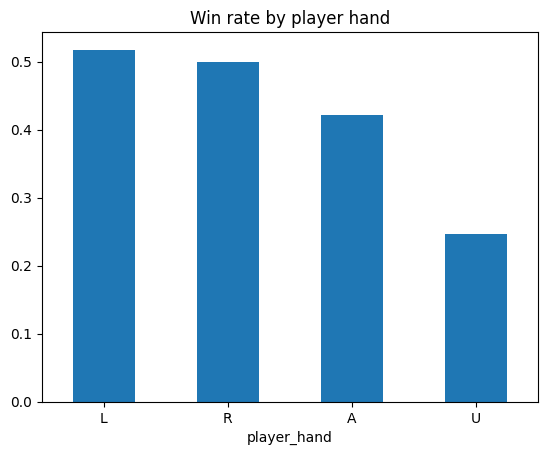

In [31]:
# Hand VS Win
chi_test('player_hand', 'win')

df.groupby('player_hand', observed=True)['win'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Win rate by player hand')
plt.xticks(rotation=0)
plt.show()

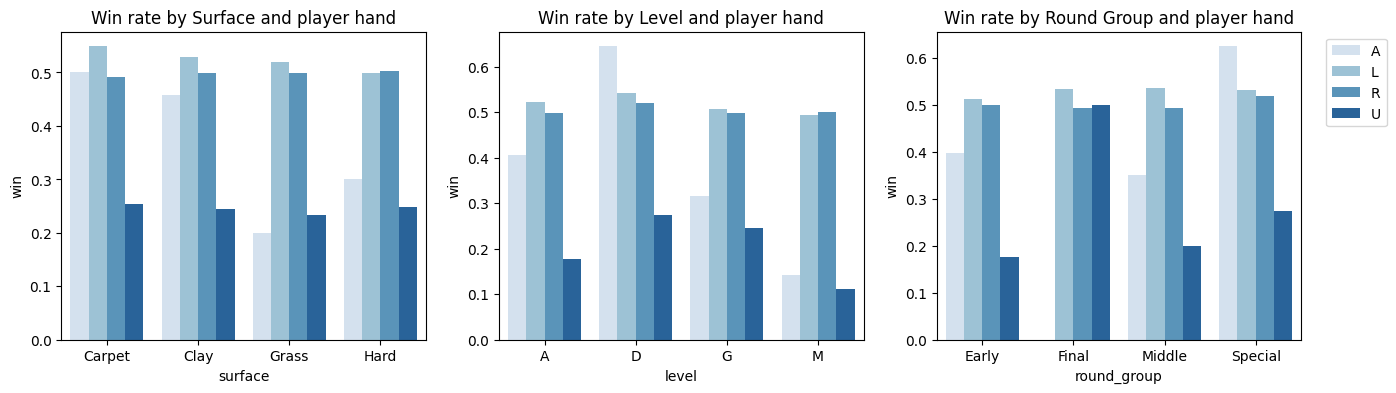

In [70]:
# Player hand by dimensions

fix, ax = plt.subplots(1, 3, figsize=(16, 4))

# player hand & surface
grouped_s = df.groupby(['surface', 'player_hand'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped_s, x='surface', y='win', palette='Blues', hue='player_hand', ax=ax[0], legend=None)
ax[0].set_title('Win rate by Surface and player hand')

# player hand & level
grouped_l = df.groupby(['level', 'player_hand'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped_l, x='level', y='win', palette='Blues', hue='player_hand', ax=ax[1], legend=None)
ax[1].set_title('Win rate by Level and player hand')

# player hand & round
grouped_r = df.groupby(['round_group', 'player_hand'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped_r, x='round_group', y='win', hue='player_hand', palette='Blues', ax=ax[2])
ax[2].set_title('Win rate by Round Group and player hand')
ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [33]:
# Results: all Statistically significant

chi_test('surface', 'player_hand', 'win')
chi_test('level', 'player_hand', 'win')
chi_test('round_group', 'player_hand', 'win')

Chi2=1033.22, p=1.018e-210
There is a statistically significant association between surface, player_hand.

Chi2=1069.83, p=6.450e-215
There is a statistically significant association between level, player_hand.

Chi2=1044.84, p=3.288e-213
There is a statistically significant association between round_group, player_hand.



####**Rank**

In [34]:
print(df['player_rank'].describe())

count    307273.000000
mean         93.106680
std         143.343658
min           1.000000
25%          25.000000
50%          57.000000
75%         101.000000
max        2159.000000
Name: player_rank, dtype: float64


Spearman's Correlation: -0.2221, p-value: 0.0000e+00



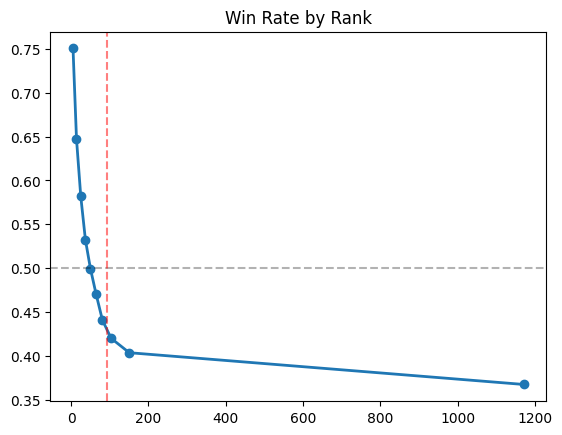

In [35]:
# Rank (1 - best, 2159 - worst) Vs Win Rate

# Use quantile bins, because the distribution has right skewness
df['rank_bin_midpoint'] = pd.qcut(df['player_rank'], q=10, duplicates='drop').apply(lambda x: x.mid)

# Significance check with Spearman
subset = df.dropna(subset=['player_rank', 'win'])
coef, p = stats.spearmanr(subset['player_rank'], subset['win'])
print(f"Spearman's Correlation: {coef:.4f}, p-value: {p:.4e}\n") # moderate negative statistically significant correlation (p-val = 0)

res = df.groupby('rank_bin_midpoint', observed=True)['win'].mean().reset_index().sort_values('rank_bin_midpoint')

plt.plot(res['rank_bin_midpoint'], res['win'], marker='o', linewidth=2)
plt.title('Win Rate by Rank')
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
plt.axvline(df['player_rank'].mean(), color='red', linestyle='--', alpha=0.5)
plt.show()


In [36]:
df['rank_bin_midpoint'].value_counts()

,count
rank_bin_midpoint,
4.9995,32001
25.0000,31987
50.0000,31627
1171.5000,30725
81.0000,30592
103.5000,30525
64.5000,30291
150.5000,30146
14.0000,29806


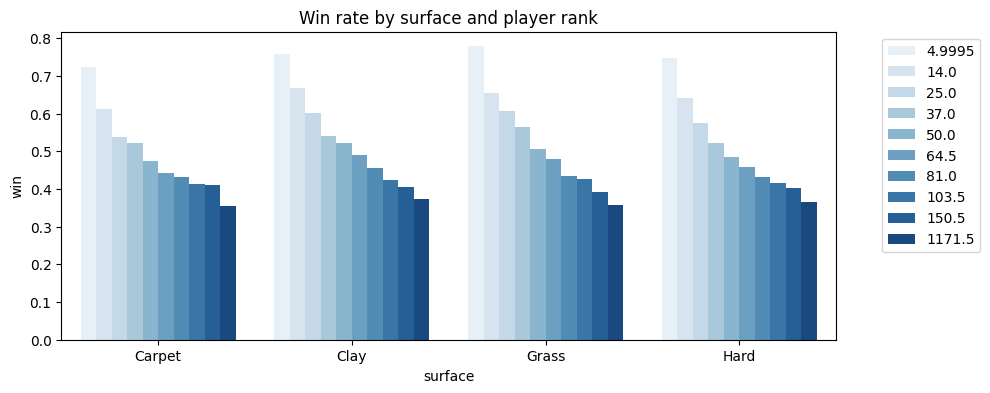

In [37]:
# Rank & Surface VS Win Rate

plt.figure(figsize=(10, 4))
grouped = df.groupby(['surface', 'rank_bin_midpoint'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped, x='surface', y='win', palette='Blues', hue='rank_bin_midpoint')
plt.title('Win rate by surface and player rank')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [38]:
chi_test('surface', 'rank_bin_midpoint', 'win')

Chi2=16270.40, p=0.000e+00
There is a statistically significant association between surface, rank_bin_midpoint.



level
A    243368
G     54496
M     48226
D     26666
F      1150
O       128
Name: count, dtype: int64
Spearman's Correlation: -0.1901, p-value: 8.0691e-11



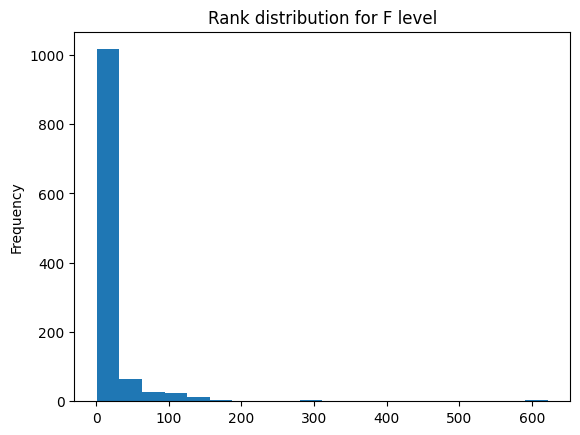

In [39]:
# Levels
print(df['level'].value_counts())

# F-level ranks: 1-622
# Significance check with Spearman
subset = df[df['level'] == 'F'].dropna(subset=['player_rank', 'win'])
coef, p = stats.spearmanr(subset['player_rank'], subset['win'])
print(f"Spearman's Correlation: {coef:.4f}, p-value: {p:.4e}\n")
# Note: F-level contains errors in data and affects visuals, so it was removed from further analysis

# F level check
df[df['level'] == 'F']['player_rank'].plot(kind='hist', bins=20)
plt.title('Rank distribution for F level')
plt.show()

df = df[df['level'].isin(['A', 'G', 'M', 'D'])] # Removing F and O levels as F contains wrong data and O is insignificant (only 128 values)

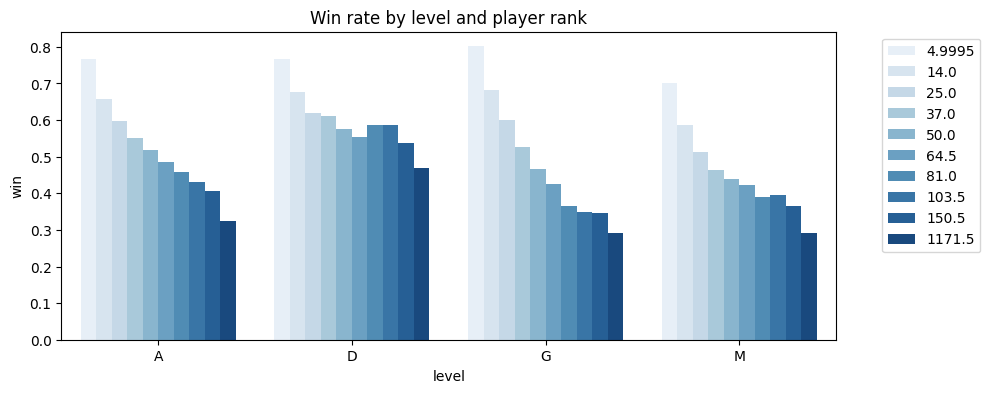

In [40]:
# Rank & Level VS Win Rate

plt.figure(figsize=(10, 4))
grouped = df.groupby(['level', 'rank_bin_midpoint'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped, x='level', y='win', palette='Blues', hue='rank_bin_midpoint')
plt.title('Win rate by level and player rank')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [41]:
chi_test('level', 'rank_bin_midpoint', 'win')

Chi2=18416.07, p=0.000e+00
There is a statistically significant association between level, rank_bin_midpoint.



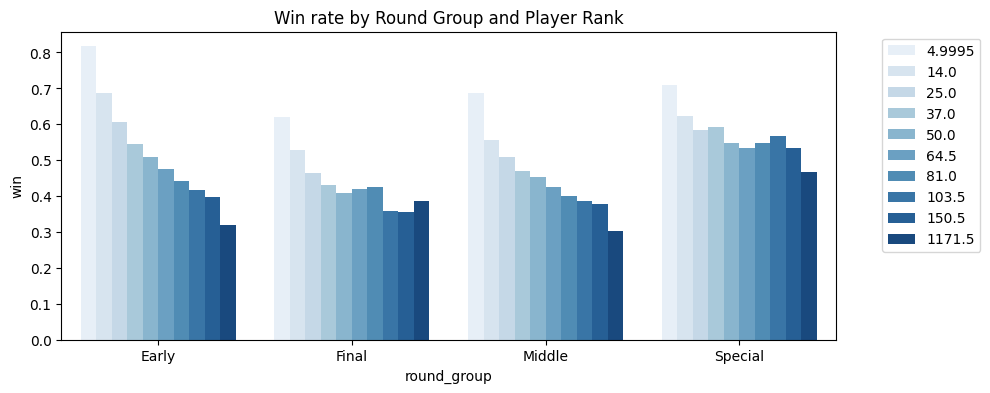

In [42]:
# Rank & Round VS Win Rate

df['round_group'] = df['round'].apply(round_group)

grouped = df.groupby(['round_group', 'rank_bin_midpoint'], observed=True)['win'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=grouped, x='round_group', y='win', hue='rank_bin_midpoint', palette='Blues')
plt.title('Win rate by Round Group and Player Rank')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [43]:
chi_test('round_group', 'rank_bin_midpoint', 'win')

Chi2=18719.26, p=0.000e+00
There is a statistically significant association between round_group, rank_bin_midpoint.



####**Age**

In [44]:
print(df['player_age'].describe())

count    372756.000000
mean         25.710909
std           4.098548
min          16.000000
25%          22.800000
50%          25.300000
75%          28.300000
max          63.600000
Name: player_age, dtype: float64


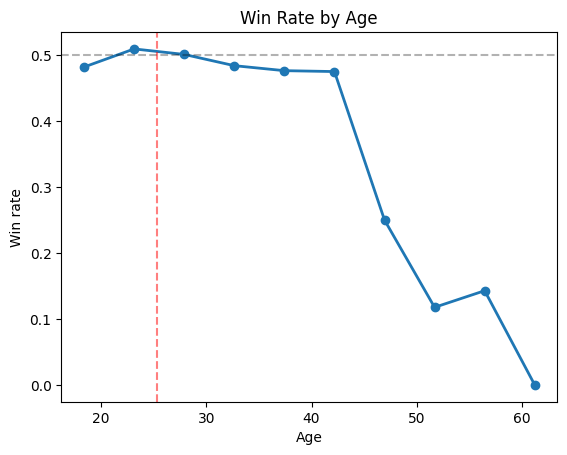

Contingency table for:
win                   0      1
age_bin_midpoint              
18.356            19333  17978
23.140            77118  80078
27.900            63584  63856
32.660            22224  20848
37.420             3501   3186
42.180              453    410
46.940              120     40
51.700               15      2
56.460                6      1
61.220                3      0


Chi2=222.97, p=4.958e-43
There is a statistically significant association between age_bin_midpoint, win.



In [71]:
# Age Vs Win Rate

df['age_bin_midpoint'] = pd.cut(df['player_age'], bins=10).apply(lambda x: x.mid)

res = df.groupby('age_bin_midpoint', observed=True)['win'].mean().reset_index()

plt.plot(res['age_bin_midpoint'], res['win'], marker='o', linewidth=2)
plt.title('Win Rate by Age')
plt.xlabel('Age')
plt.ylabel('Win rate')
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
plt.axvline(df['player_age'].median(), color='red', linestyle='--', alpha=0.5)
plt.show()

chi_test('age_bin_midpoint', 'win')


Spearman's Correlation: -0.0745, p-value: 0.0000e+00



Text(0, 0.5, 'Rank')

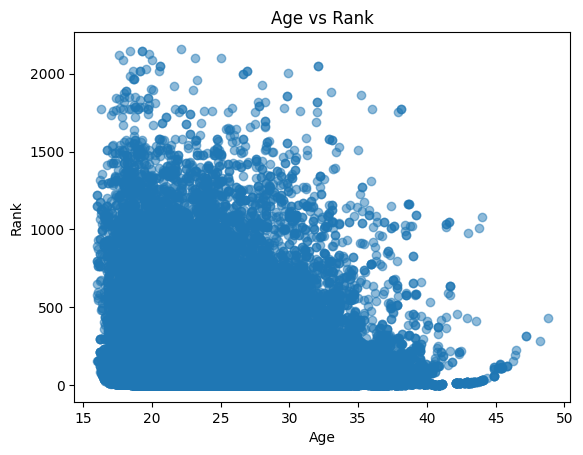

In [46]:
# Age VS Rank Correlation

subset = df.dropna(subset=['player_age', 'player_rank'])
coef, p = stats.spearmanr(subset['player_age'], subset['player_rank'])
print(f"Spearman's Correlation: {coef:.4f}, p-value: {p:.4e}\n")

plt.scatter(df['player_age'], df['player_rank'], alpha=0.5)
plt.xlabel('Age')
plt.title('Age vs Rank')
plt.ylabel('Rank')

The Spearman correlation between player age and rank is weak and negative
(r = -0.07, p < 0.001), suggesting a slight tendency for older players to
have better rankings. However, this relationship is likely driven by
survivor bias: younger players in the dataset represent the full spectrum
of skill levels, while older players are disproportionately those who
sustained long careers — indicating above-average ability. Therefore, age
alone should not be interpreted as a predictor of ranking.

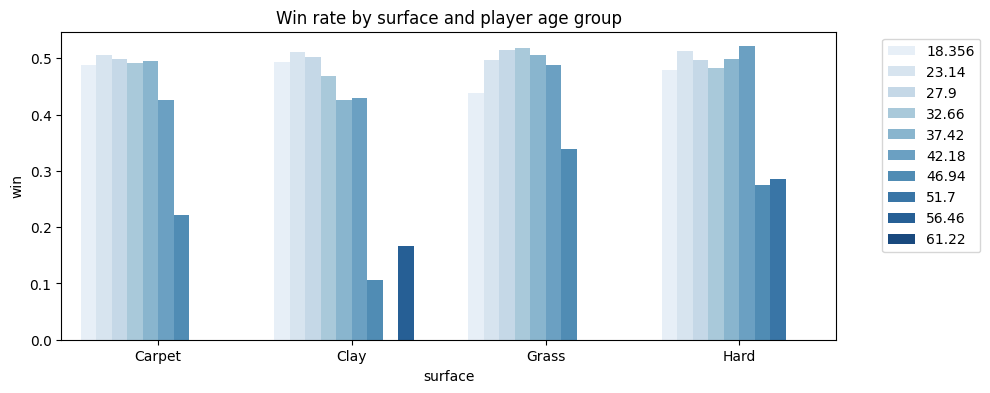

In [47]:
# Age & Surface VS Win Rate

plt.figure(figsize=(10, 4))
grouped = df.groupby(['surface', 'age_bin_midpoint'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped, x='surface', y='win', palette='Blues', hue='age_bin_midpoint')
plt.title('Win rate by surface and player age group')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [48]:
chi_test('surface', 'age_bin_midpoint', 'win')

Chi2=381.24, p=2.595e-60
There is a statistically significant association between surface, age_bin_midpoint.



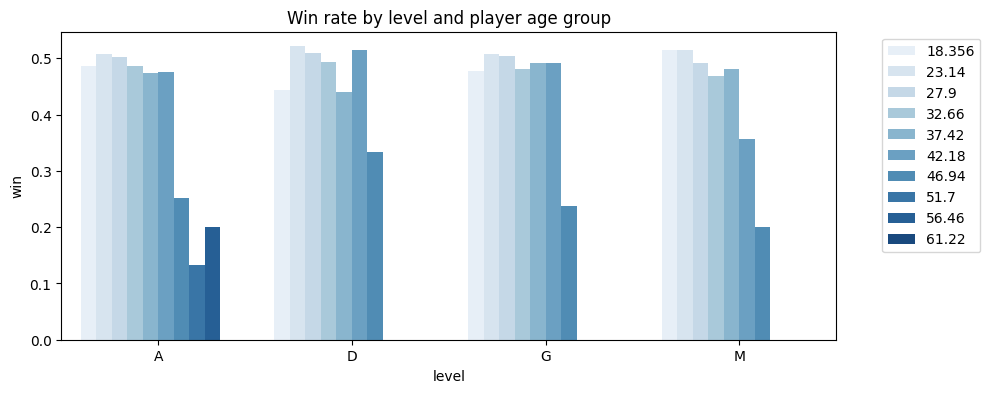

In [49]:
# Age & Level VS Win Rate

plt.figure(figsize=(10, 4))
grouped = df.groupby(['level', 'age_bin_midpoint'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped, x='level', y='win', palette='Blues', hue='age_bin_midpoint')
plt.title('Win rate by level and player age group')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [50]:
chi_test('level', 'age_bin_midpoint', 'win')

Chi2=304.38, p=1.154e-45
There is a statistically significant association between level, age_bin_midpoint.



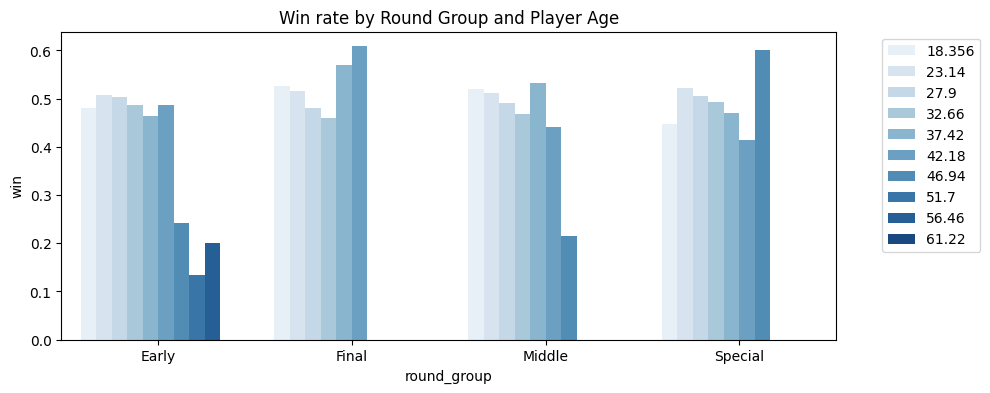

In [51]:
# Age & Round VS Win Rate

grouped = df.groupby(['round_group', 'age_bin_midpoint'], observed=True)['win'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=grouped, x='round_group', y='win', hue='age_bin_midpoint', palette='Blues')
plt.title('Win rate by Round Group and Player Age')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [52]:
chi_test('round_group', 'age_bin_midpoint', 'win')

Chi2=345.10, p=1.148e-53
There is a statistically significant association between round_group, age_bin_midpoint.



####**Height**

In [53]:
print(df['player_height'].describe())

count    372756.000000
mean        184.483585
std           6.392351
min         160.000000
25%         180.000000
50%         184.491337
75%         188.000000
max         211.000000
Name: player_height, dtype: float64


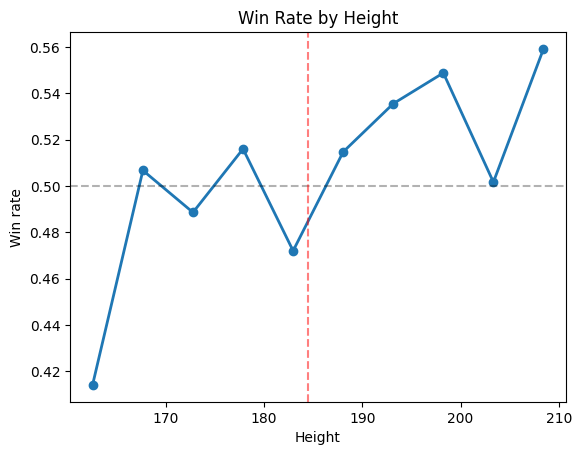

Contingency table for:
win                      0      1
height_bin_midpoint              
162.5245               167    118
167.6500              3695   3796
172.7500             16095  15377
177.8500             34274  36547
182.9500             73008  65266
188.0500             34663  36771
193.1500             14182  16356
198.2500              7754   9434
203.3500              1764   1776
208.4500               755    958


Chi2=937.87, p=4.274e-196
There is a statistically significant association between height_bin_midpoint, win.



In [54]:
# Height Vs Win Rate

df['height_bin_midpoint'] = pd.cut(df['player_height'], bins=10).apply(lambda x: x.mid)
res = df.groupby('height_bin_midpoint', observed=True)['win'].mean().reset_index()

plt.plot(res['height_bin_midpoint'], res['win'], marker='o', linewidth=2)
plt.title('Win Rate by Height')
plt.xlabel('Height')
plt.ylabel('Win rate')
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
plt.axvline(df['player_height'].mean(), color='red', linestyle='--', alpha=0.5)
plt.show()

chi_test('height_bin_midpoint', 'win')

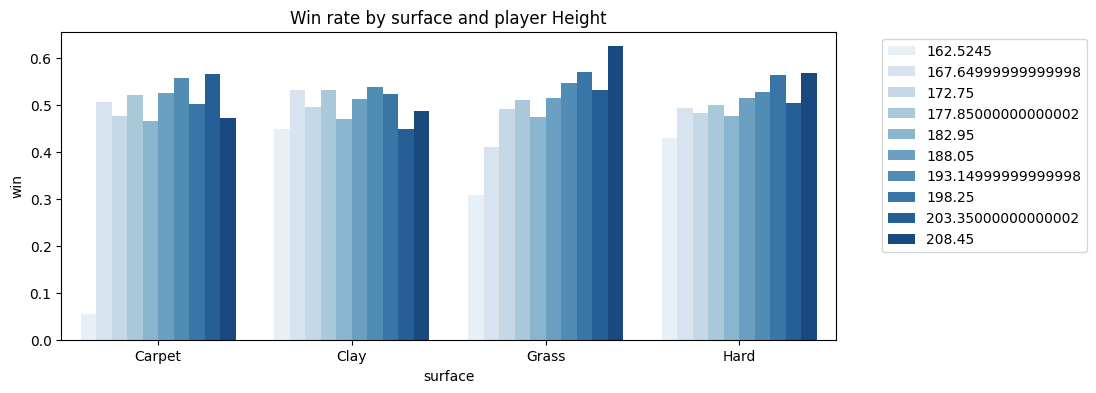

In [55]:
# Height & Surface VS Win Rate

plt.figure(figsize=(10, 4))
grouped = df.groupby(['surface', 'height_bin_midpoint'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped, x='surface', y='win', palette='Blues', hue='height_bin_midpoint')
plt.title('Win rate by surface and player Height')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [56]:
chi_test('surface', 'height_bin_midpoint', 'win')

Chi2=1137.89, p=2.828e-213
There is a statistically significant association between surface, height_bin_midpoint.



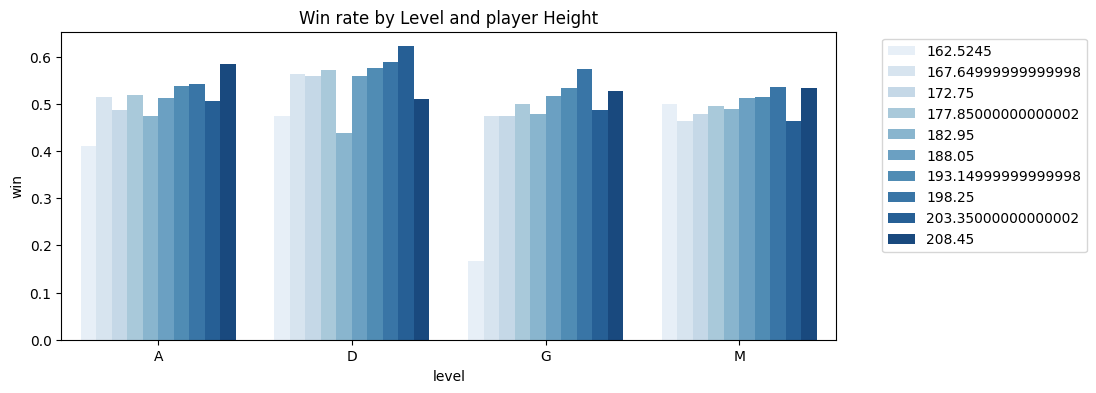

In [57]:
# Height & Level VS Win Rate

plt.figure(figsize=(10, 4))
grouped = df.groupby(['level', 'height_bin_midpoint'], observed=True)['win'].mean().reset_index()
sns.barplot(data=grouped, x='level', y='win', palette='Blues', hue='height_bin_midpoint')
plt.title('Win rate by Level and player Height')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [58]:
chi_test('level', 'height_bin_midpoint', 'win')

Chi2=1245.87, p=5.364e-236
There is a statistically significant association between level, height_bin_midpoint.



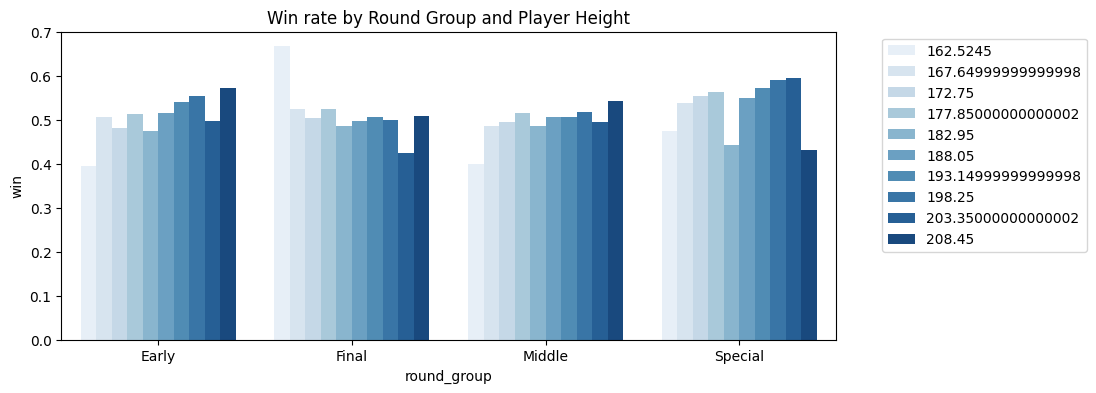

In [59]:
# Height & Round VS Win Rate

grouped = df.groupby(['round_group', 'height_bin_midpoint'], observed=True)['win'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=grouped, x='round_group', y='win', hue='height_bin_midpoint', palette='Blues')
plt.title('Win rate by Round Group and Player Height')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [60]:
chi_test('round_group', 'height_bin_midpoint', 'win')

Chi2=1202.87, p=6.110e-227
There is a statistically significant association between round_group, height_bin_midpoint.



###**Differences analysis**

In [69]:
# 'rank_diff', 'age_diff', and 'height_diff' have significant correlation with Wins,
# but only rank_diff has moderate correlation coefficient indicating linear correlation

for col in ['rank_diff', 'age_diff', 'height_diff']:
    subset = df.dropna(subset=[col])
    coef, p = stats.spearmanr(subset[col], subset['win'])
    print(f"{col}: r={coef:.4f}, p={p:.2e}")

rank_diff: r=-0.3444, p=0.00e+00
age_diff: r=-0.0112, p=8.61e-12
height_diff: r=0.0268, p=2.68e-60


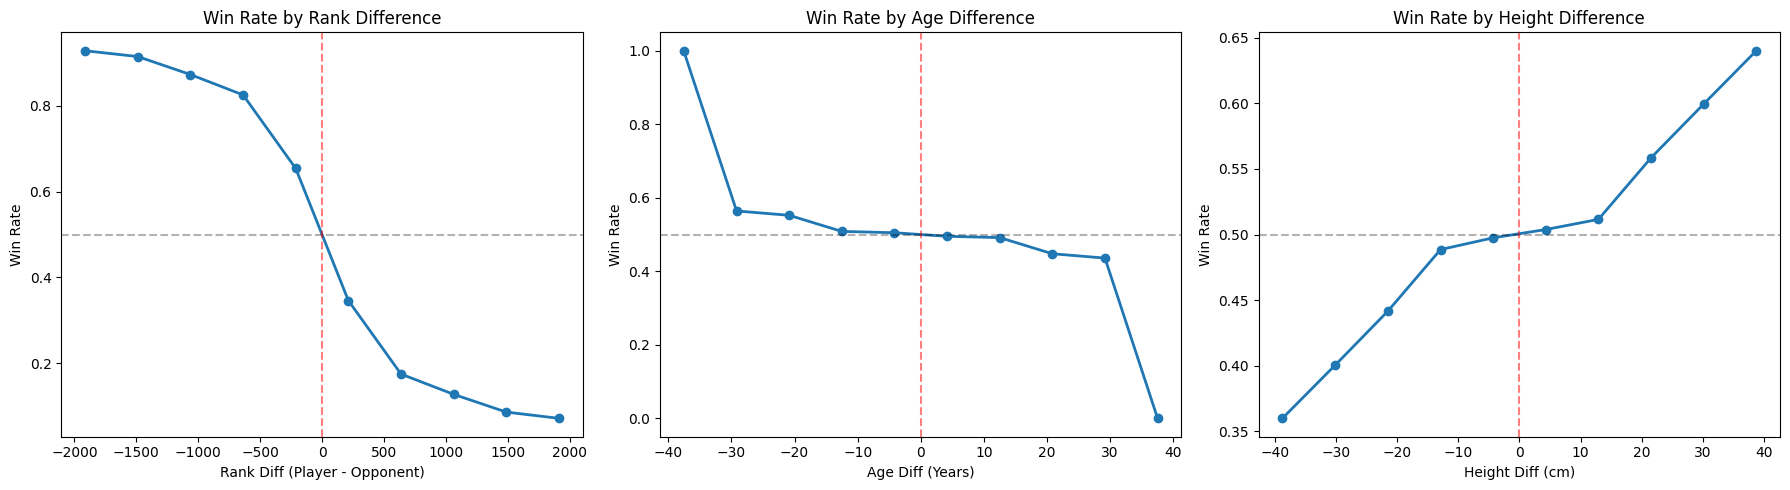

In [62]:
df['rank_diff_midpoint'] = pd.cut(df['rank_diff'], bins=10).apply(lambda x: x.mid)
result_r = df.groupby('rank_diff_midpoint', observed=True)['win'].mean().reset_index()

df['age_diff_midpoint'] = pd.cut(df['age_diff'], bins=10).apply(lambda x: x.mid)
result_a = df.groupby('age_diff_midpoint', observed=True)['win'].mean().reset_index()

df['height_diff_midpoint'] = pd.cut(df['height_diff'], bins=10).apply(lambda x: x.mid)
result_h = df.groupby('height_diff_midpoint', observed=True)['win'].mean().reset_index()



fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(result_r['rank_diff_midpoint'], result_r['win'], marker='o', linewidth=2)
ax[0].set_title('Win Rate by Rank Difference')
ax[0].set_xlabel('Rank Diff (Player - Opponent)')

ax[1].plot(result_a['age_diff_midpoint'], result_a['win'], marker='o', linewidth=2)
ax[1].set_title('Win Rate by Age Difference')
ax[1].set_xlabel('Age Diff (Years)')

ax[2].plot(result_h['height_diff_midpoint'], result_h['win'], marker='o', linewidth=2)
ax[2].set_title('Win Rate by Height Difference')
ax[2].set_xlabel('Height Diff (cm)')

# Common Setting
for a in ax:
    a.axhline(0.5, color='black', linestyle='--', alpha=0.3)
    a.axvline(0, color='red', linestyle='--', alpha=0.5)
    a.set_ylabel('Win Rate')

plt.tight_layout()
plt.show()

**Rank**
The first chart shows a very strong "S-curve" relationship between rank difference and win probability.
* A *1,500-point* rank advantage gives *>90%* win probability.
* Once the difference crosses zero, win rate drops sharply. This suggests that the ranking system used here is highly accurate at predicting performance.

**Age**
For the most part, age is a relatively "flat" factor, except at the extreme ends.

* Between -20 and +20 years, win rate stays near 50% — This implies that experience and youth often balance each other out.

* Extreme values (±40 years) show 100%/0% win rates, likely due to very small sample sizes, though it underscores that a 40-year advantage/disadvantage is nearly impossible to overcome.

**Height**
A steady, linear relationship between height and winning.

Unlike age, every extra centimeter consistently increases win probability. A 40cm advantage correlates with ~64% win rate — not as decisive as rank, but a significant physical "bias".

In [63]:
for s in df['surface'].unique():
    subset = df[df['surface'] == s].dropna(subset=['rank_diff', 'win'])
    coef, _ = stats.spearmanr(subset['rank_diff'], subset['win'])
    print(s, coef)

Hard -0.3492119630626575
Clay -0.34018902618783314
Grass -0.3335231512091112
Carpet -0.34978440742482275


In [64]:
def plot_winrate_by_group(ax, df, group_col, metric, title, color_list):
    for i, val in enumerate(df[group_col].dropna().unique()):
        subset = df[df[group_col] == val]

        result = (
            subset
            .groupby(metric, observed=True)['win']
            .mean()
            .reset_index()
            .sort_values(metric)
        )

        ax.plot(
            result[metric],
            result['win'],
            label=val,
            marker='o',
            markersize=4,
            color=color_list[i % len(color_list)],
            linewidth=2
        )

    ax.set_title(title)
    ax.set_xlabel(f'{metric} (Player - Opponent)')
    ax.legend(title=group_col)

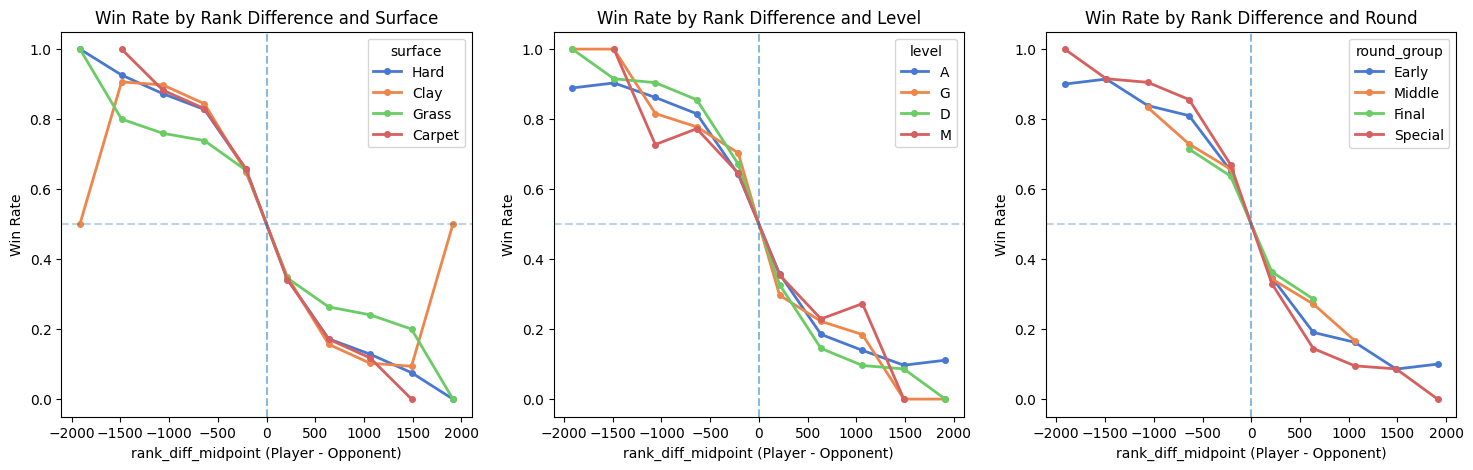

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

color_list = sns.color_palette("muted", n_colors=4)

plot_winrate_by_group(ax[0], df, 'surface', 'rank_diff_midpoint', 'Win Rate by Rank Difference and Surface', color_list)
plot_winrate_by_group(ax[1], df, 'level', 'rank_diff_midpoint', 'Win Rate by Rank Difference and Level', color_list)
plot_winrate_by_group(ax[2], df, 'round_group', 'rank_diff_midpoint', 'Win Rate by Rank Difference and Round', color_list)

for a in ax:
    a.axhline(0.5, linestyle='--', alpha=0.3)
    a.axvline(0, linestyle='--', alpha=0.5)
    a.set_ylabel('Win Rate')

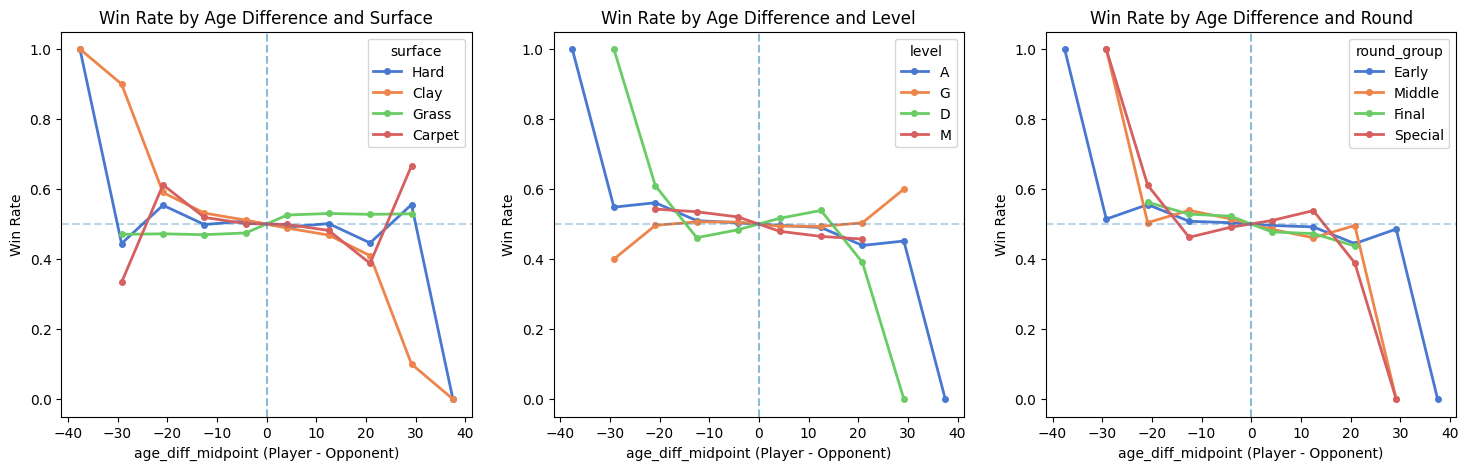

In [66]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

plot_winrate_by_group(ax[0], df, 'surface', 'age_diff_midpoint', 'Win Rate by Age Difference and Surface', color_list)
plot_winrate_by_group(ax[1], df, 'level', 'age_diff_midpoint', 'Win Rate by Age Difference and Level', color_list)
plot_winrate_by_group(ax[2], df, 'round_group', 'age_diff_midpoint', 'Win Rate by Age Difference and Round', color_list)

for a in ax:
    a.axhline(0.5, linestyle='--', alpha=0.3)
    a.axvline(0, linestyle='--', alpha=0.5)
    a.set_ylabel('Win Rate')

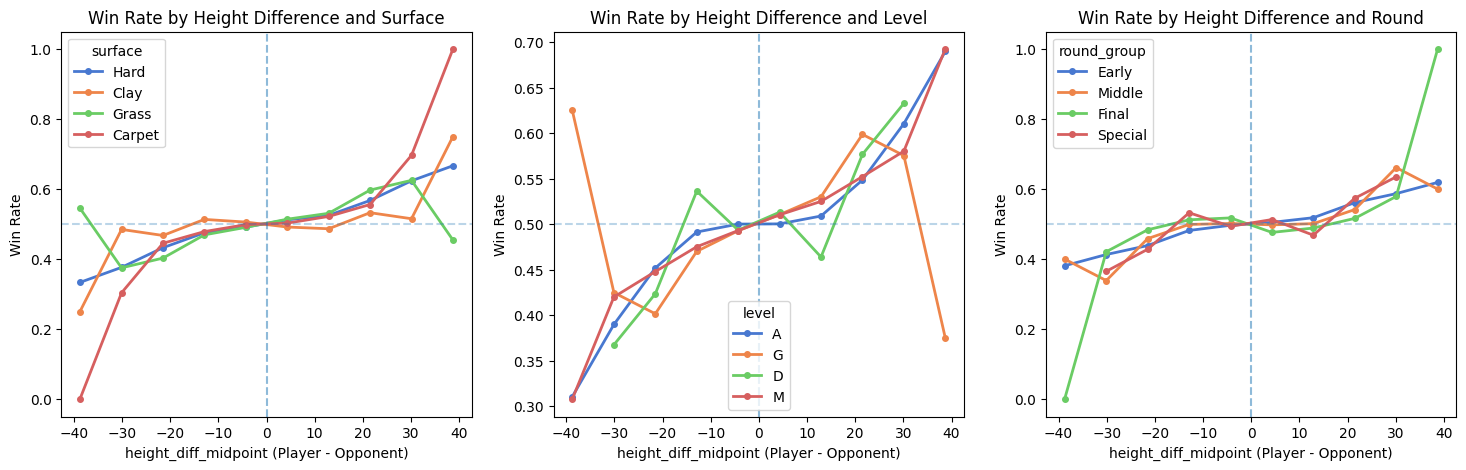

In [67]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

plot_winrate_by_group(ax[0], df, 'surface', 'height_diff_midpoint', 'Win Rate by Height Difference and Surface', color_list)
plot_winrate_by_group(ax[1], df, 'level', 'height_diff_midpoint', 'Win Rate by Height Difference and Level', color_list)
plot_winrate_by_group(ax[2], df, 'round_group', 'height_diff_midpoint', 'Win Rate by Height Difference and Round', color_list)

for a in ax:
    a.axhline(0.5, linestyle='--', alpha=0.3)
    a.axvline(0, linestyle='--', alpha=0.5)
    a.set_ylabel('Win Rate')

###Save to csv

In [68]:
df.to_csv('tennis_cleaned.csv', index=False)

# INSIGHTS:

*Note: Since each match produces one win and one loss, the baseline win rate is ~50%.*

## Separate metrics

**Players Hand**

Left-handed players have a slightly higher win rate (\~52%), followed by right-handed (\~50%) and ambidextrous players (\~42%). The lowest win rate is observed for undefined (\~25%), which likely reflects missing data or inexperienced players.

These patterns are generally consistent across surfaces, levels, and rounds, with only minor variations:

Surfaces:
* Hard: Left = Right (~50%)
* Carpet: Left (55%) slightly outperforms Right (49%) and Ambidextrous (50%)

An exception appears at D-level, where ambidextrous players show an unusually high win rate (>65%), which may be due to small sample size.

Rounds:
* In *final rounds*, win rates are similar across all groups (\~50%), with a slight advantage for left-handed players (~52%).
* In *special rounds (RR, BR, ER)*, ambidextrous players show higher win rates (~63%), though this may also be sample-size driven.

*Conclusion:* Player hand has a marginal effect, but differences are small and inconsistent.

---
**Players Rank:**

Rank is the strongest and most consistent predictor of match outcome.

Lower (better) rank corresponds to higher win rates (from \~76%). This relationship holds across most surfaces, levels, and rounds, with minor deviations (e.g., D-level, special and final rounds).

*Conclusion:* Rank is a highly reliable predictor of performance.

---

**Players Age**

Range: 16-63

Mean/median: ~25, indicating that most players are concentrated around this age

Win rate remains relatively stable (~50%) between ages 15-40. After ~40, performance declines noticeably.

Some surface- and round-specific patterns:

* Grass: win rate increases with age until ~40, then declines

* Finals: older players (\~40) show higher win rates (\~60%)

Overall, results are inconsistent across segments.

*Conclusion:* Age alone is not a reliable predictor of performance.

---

**Age VS Rank**

Spearman correlation between age and rank is weak and negative (r = -0.07, p < 0.001), suggesting a slight tendency for older players to have better rankings.

However, this is likely driven by survivor bias: weaker players drop out earlier, while older players tend to be more skilled and experienced.

*Conclusion:* Age should not be interpreted as a causal factor for ranking.

---

**Player Height**

There is a weak but consistent trend: taller players tend to have slightly higher win rates.

Shorter players generally have lower win probability, although this pattern does not hold in finals.

*Conclusion:* Height may have a small positive effect, but it is not a strong standalone predictor.


###**Final takeaway (separate metrics)**

* Rank - strongest factor
* Hand - minor effect
* Age & height - weak and inconsistent predictors


## Differences (Player vs Opponent)

**Rank Difference**

There is a strong S-shaped relationship between rank difference and win probability:
* 1,500-point rank advantage gives >90% win probability.
* Once the difference crosses zero, win rate drops sharply.

This indicates that the ranking system is highly predictive.

---

**Age Difference**

For the most part, age is a relatively "flat" factor, except at the extreme ends.

* Within ±20 years, win rate stays near 50%

* Extreme values (±40 years) show 100%/0% win rates, likely due to very small sample sizes, though it underscores that a 40-year advantage/disadvantage is nearly impossible to overcome.

*Conclusion:* Age difference matters only at extreme values.

---

**Height Difference**

Height difference shows a steady positive relationship with win probability.

* Each additional centimeter slightly increases the chance of winning.
A ~40 cm advantage corresponds to ~64% win rate.

*Conclusion:* Height difference has a measurable, but moderate effect.

---

**Segment deviations**

Some deviations from overall trends:

* Rank behaves slightly differently on clay
* Age shows reversed patterns on carpet and G-level
* Height: some segments (e.g., grass, G-level) show deviations from the overall trend, possibly due to smaller sample sizes or interaction effects.

These inconsistencies suggest interaction effects between variables.

##**Overall conclusion**


| Metric                | Strength | Consistency | Where it works well                 | Notable deviations / limitations                  |
| --------------------- | -------- | ----------- | ----------------------------------- | ------------------------------------------------- |
| **Rank**              | Strong   | High        | All surfaces, levels, rounds        | Slight deviations in D-level, Special, Finals     |
| **Rank Difference**   | Very Strong   | High        | Globally consistent (S-curve)       | Slight variation on clay                          |
| **Height**            | Weak     | Low         | Slight overall positive trend       | Not valid in finals, inconsistent across segments |
| **Height Difference** | Moderate | Medium      | General linear trend across dataset | Reversed trend on grass and G-level               |
| **Age**               | Weak     | Low         | Some patterns in grass and finals   | Inconsistent across levels, surfaces, rounds      |
| **Age Difference**    | Weak     | Medium      | Only at extreme gaps                | Flat in most realistic ranges (±20 years)         |
| **Hand**              | Weak     | Medium      | Slight advantage for left-handed    | Very small differences, unstable in segments      |


The analysis shows that predictive power is concentrated in ranking-based features, while demographic and physical attributes have limited and context-dependent impact.

data was taken from https://github.com/JeffSackmann/tennis_atp

Tennis databases, files, and algorithms by Jeff Sackmann / Tennis Abstract is licensed under a Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License.
Based on a work at https://github.com/JeffSackmann.